Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


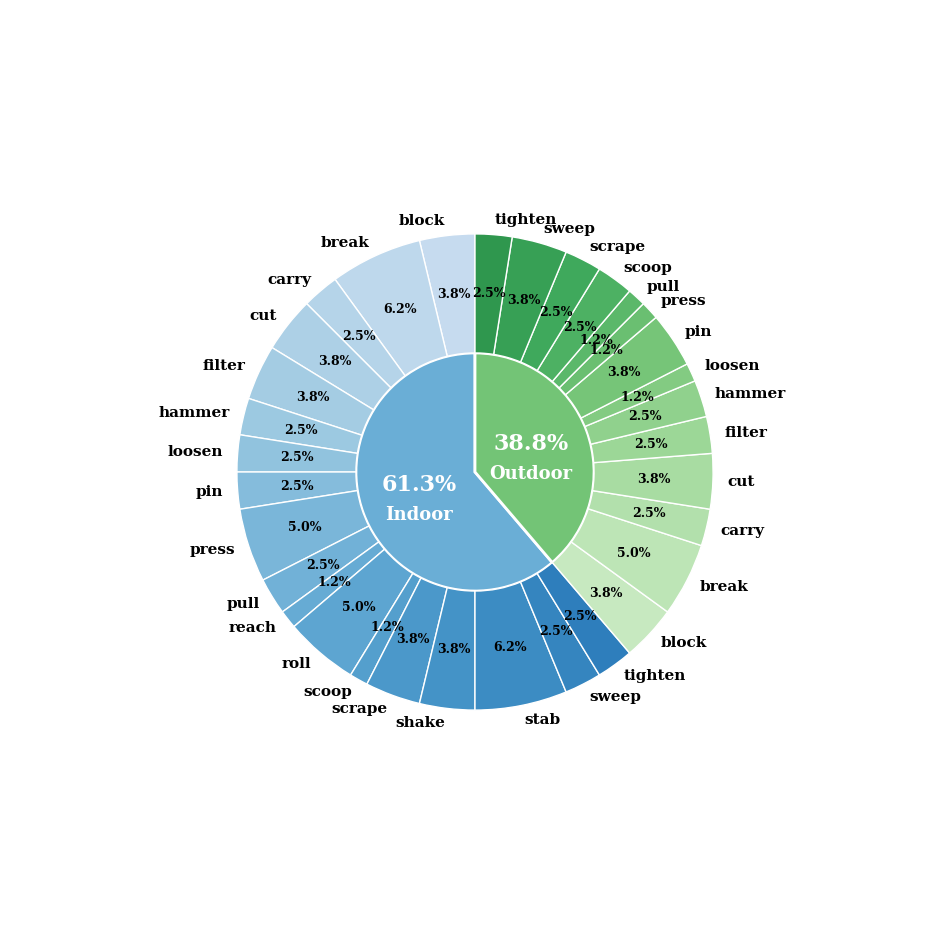

Saved:
- double_pie_indoor_outdoor_action_category.pdf
- double_pie_indoor_outdoor_action_category.png
- double_pie_counts.csv


In [ ]:
import json
from pathlib import Path
from collections import OrderedDict

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np


json_path = Path("/home/ubuntu/data_engine/tasks/finalized_tasks.json")
with open(json_path, "r") as f:
    data = json.load(f)

rows = []
for action_category, tasks in data.items():
    if isinstance(tasks, list):
        for t in tasks:
            rows.append({
                "action_category": str(action_category),
                "task_goal": t.get("task_goal", "") if isinstance(t, dict) else str(t),
                "environment": t.get("environment", "") if isinstance(t, dict) else ""
            })

df_tasks = pd.DataFrame(rows)

counts = (
    df_tasks.groupby(["action_category", "environment"])
    .size()
    .reset_index(name="count")
)

pivot_df = (
    counts.pivot(index="action_category", columns="environment", values="count")
    .fillna(0)
)

pivot_df = pivot_df.sort_index()

indoor_distribution = OrderedDict(
    (cat, int(val)) for cat, val in pivot_df["Indoor"].items() if val > 0
)
outdoor_distribution = OrderedDict(
    (cat, int(val)) for cat, val in pivot_df["Outdoor"].items() if val > 0
)

indoor_s = pd.Series(indoor_distribution, name="Indoor")
outdoor_s = pd.Series(outdoor_distribution, name="Outdoor")

df = pd.concat([indoor_s, outdoor_s], axis=1).fillna(0)

inner_sizes = df.sum()
inner_labels_raw = inner_sizes.index.tolist()
grand_total = inner_sizes.sum()

outer_labels_with_env = []
outer_sizes = []
outer_colors_mapping = []

for category, value in indoor_s[indoor_s > 0].items():
    outer_labels_with_env.append(f"Indoor - {category}")
    outer_sizes.append(value)
    outer_colors_mapping.append("Indoor")

for category, value in outdoor_s[outdoor_s > 0].items():
    outer_labels_with_env.append(f"Outdoor - {category}")
    outer_sizes.append(value)
    outer_colors_mapping.append("Outdoor")

inner_pcts = (inner_sizes / grand_total) * 100
inner_labels = inner_labels_raw

outer_pcts = (np.array(outer_sizes) / grand_total) * 100
outer_labels_categories_only = [label.split(" - ")[1] for label in outer_labels_with_env]
outer_labels = outer_labels_categories_only

cmap_indoor = plt.cm.Blues
cmap_outdoor = plt.cm.Greens

num_indoor_outer_slices = sum(1 for x in outer_colors_mapping if x == "Indoor")
num_outdoor_outer_slices = sum(1 for x in outer_colors_mapping if x == "Outdoor")

# Lighter ranges (paper-friendly)
outer_colors = list(cmap_indoor(np.linspace(0.25, 0.70, max(num_indoor_outer_slices, 1)))[:num_indoor_outer_slices]) + \
               list(cmap_outdoor(np.linspace(0.25, 0.70, max(num_outdoor_outer_slices, 1)))[:num_outdoor_outer_slices])

inner_colors = [cmap_indoor(0.50), cmap_outdoor(0.50)]

fig, ax = plt.subplots(figsize=(12, 12))
ax.axis("equal")

width = 0.32
inner_radius = 0.32

shadow_layers = [
    {"offset": 0.06, "opacity": "60", "zorder": 0},
    {"offset": 0.04, "opacity": "40", "zorder": 0},
    {"offset": 0.02, "opacity": "20", "zorder": 0},
]

for layer in shadow_layers:
    shadow_wedges, _ = ax.pie(
        inner_sizes,
        radius=inner_radius,
        colors=[f'#000000{layer["opacity"]}' for _ in range(len(inner_sizes))],
        wedgeprops=dict(edgecolor="none"),
        startangle=90,
        labels=None,
        textprops=None
    )
    for wedge in shadow_wedges:
        wedge.set_center((layer["offset"], -layer["offset"]))
        wedge.set_zorder(layer["zorder"])

wedges1, _ = ax.pie(
    inner_sizes,
    radius=inner_radius,
    colors=inner_colors,
    wedgeprops=dict(edgecolor="w", linewidth=2),
    startangle=90,
    labels=None,
    textprops={"fontsize": 10, "fontweight": "bold", "color": "white"},
)

inner_radius_center = inner_radius / 2
for wedge, pct, label in zip(wedges1, inner_pcts, inner_labels):
    theta = np.radians((wedge.theta1 + wedge.theta2) / 2)
    x = inner_radius_center * np.cos(theta)
    y = inner_radius_center * np.sin(theta)

    ax.text(
        x, y + 0.02, f"{pct:.1f}%",
        ha="center", va="center",
        fontsize=16, fontweight="bold", color="white"
    )
    ax.text(
        x, y - 0.06, label,
        ha="center", va="center",
        fontsize=13, fontweight="bold", color="white"
    )

outer_radius = inner_radius + width
wedges2, texts2 = ax.pie(
    outer_sizes,
    radius=outer_radius,
    colors=outer_colors,
    wedgeprops=dict(width=width, edgecolor="w"),
    startangle=90,
    labels=outer_labels,
    labeldistance=1.06,
    textprops={"fontsize": 11, "color": "black", "fontweight": "bold"}
)

outer_radius_center = inner_radius + width / 2
for wedge, pct in zip(wedges2, outer_pcts):
    theta = np.radians((wedge.theta1 + wedge.theta2) / 2)
    x = outer_radius_center * np.cos(theta)
    y = outer_radius_center * np.sin(theta)
    ax.text(
        x, y, f"{pct:.1f}%",
        ha="center", va="center",
        fontsize=9, color="black", fontweight="bold"
    )

plt.savefig("dataset_action_distribution.pdf", dpi=600, bbox_inches="tight")

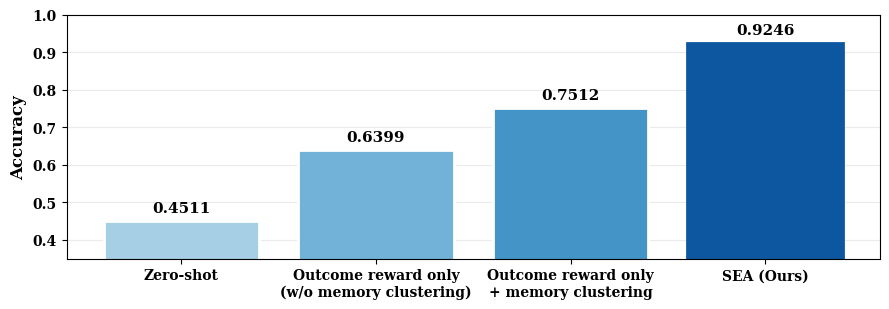

In [3]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# ----------------------------
# Style (match your previous figures)
# ----------------------------
matplotlib.rc('text', usetex=False)
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"

# ----------------------------
# Data
# ----------------------------
methods = [
    "Zero-shot",
    "Outcome reward only\n(w/o memory clustering)",
    "Outcome reward only\n+ memory clustering",
    r"SEA (Ours)"
]

accuracies = [0.4511, 0.6399, 0.7512, 0.9246]

x = np.arange(len(methods))

# ----------------------------
# Colors (paper-friendly gradient)
# ----------------------------
cmap = plt.cm.Blues
colors = cmap(np.linspace(0.35, 0.75, len(methods)))

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.set_axisbelow(True)
ax.yaxis.grid(True, linewidth=0.8, alpha=0.25)

bars = ax.bar(
    x,
    accuracies,
    color=colors,
    edgecolor="white",
    linewidth=2
)

# Highlight Ours slightly darker
bars[-1].set_color(cmap(0.85))

# Value labels
for xi, acc in zip(x, accuracies):
    ax.text(
        xi,
        acc + 0.015,
        f"{acc:.4f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Axes formatting
ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=10, fontweight="bold")
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_ylim(0.35, 1.0)

plt.tight_layout()

# ----------------------------
# Save
# ----------------------------
plt.savefig("ablation_medcase_bar.pdf", dpi=600, bbox_inches="tight")
plt.savefig("ablation_medcase_bar.png", dpi=400, bbox_inches="tight")
plt.show()